In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# 1. 样本数量
n_samples = 200
n_inf = n_samples // 2
n_norm = n_samples - n_inf

# 2. 构建 12 个基因表达矩阵
# 炎症组 
IL6_inf   = np.random.normal(loc=12, scale=3, size=100)
TNF_inf   = np.random.normal(loc=10, scale=2, size=100)
CXCL8_inf = np.random.normal(loc=14, scale=3, size=100)

KLF2_inf  = np.random.normal(loc=4, scale=1, size=100)
PPARG_inf = np.random.normal(loc=5, scale=1, size=100)
S1PR1_inf = np.random.normal(loc=3, scale=1, size=100)
noise_inf = [np.random.normal(8, 2, 100) for _ in range(6)]

X_inf = np.column_stack([
    IL6_inf, TNF_inf, CXCL8_inf,
    KLF2_inf, PPARG_inf, S1PR1_inf,
    *noise_inf
])

# 炎症组的标签为1（正类），所以标签集y要化为1向量
y_inf = np.ones((100,1))

# 健康组（Normal = 0）
IL6_norm   = np.random.normal(loc=6, scale=2, size=100)
TNF_norm   = np.random.normal(loc=5, scale=2, size=100)
CXCL8_norm = np.random.normal(loc=7, scale=2, size=100)

KLF2_norm  = np.random.normal(loc=8, scale=1, size=100)
PPARG_norm = np.random.normal(loc=9, scale=1, size=100)
S1PR1_norm = np.random.normal(loc=7, scale=1, size=100)

# Gene7–Gene12（6 个噪声基因）
noise_norm = [np.random.normal(loc=8, scale=2, size=100) for _ in range(6)]

# 拼接
X_norm = np.column_stack([
    IL6_norm, TNF_norm, CXCL8_norm,
    KLF2_norm, PPARG_norm, S1PR1_norm,
    *noise_norm
])

# 健康组标签为0（非正类），所以标签集要化为0向量
y_norm = np.zeros((100,1))

# 3. 合并
X = np.vstack([X_inf, X_norm])
y = np.vstack([y_inf, y_norm])

# 4. 标准化
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# 5. 手动逻辑回归
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

X_aug = np.hstack([np.ones((200,1)), X_scaled])  # 加截距
w = np.zeros((13,1))  # 12 基因 + 截距

lr = 0.01
epochs = 10000

for epoch in range(epochs):
    z = X_aug.dot(w)
    y_hat = sigmoid(z)
    grad = (1/200) * X_aug.T.dot(y_hat - y)
    w -= lr * grad

theta0 = w[0,0]
theta = w[1:,0]

# 6. 手动 PCA（12 → 2）
Xc = X_scaled - X_scaled.mean(axis=0)
cov = np.cov(Xc.T)
eigvals, eigvecs = np.linalg.eigh(cov)
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx[:2]]
X_pca = Xc.dot(eigvecs)


# 绘制 PCA 散点图
# -------------------------------

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y.flatten(), cmap='bwr', alpha=0.7)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA Scatter Plot (Manual PCA)")
plt.colorbar(label="Class (0=Normal, 1=Inflammation)")
plt.show()


# 7. 决策边界
x1 = np.linspace(X_pca[:,0].min(), X_pca[:,0].max(), 300)
x2 = np.linspace(X_pca[:,1].min(), X_pca[:,1].max(), 300)
X1, X2 = np.meshgrid(x1, x2)

grid = np.c_[X1.ravel(), X2.ravel()]
grid_original = grid.dot(eigvecs.T) + X_scaled.mean(axis=0)

Z = theta0 + grid_original.dot(theta)
P = sigmoid(Z).reshape(X1.shape)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y.flatten(), cmap='bwr', alpha=0.7)
plt.contour(X1, X2, P, levels=[0.5], colors='k', linestyles='--')
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Manual Logistic Regression Decision Boundary (Inflammation vs Normal)")
plt.show()

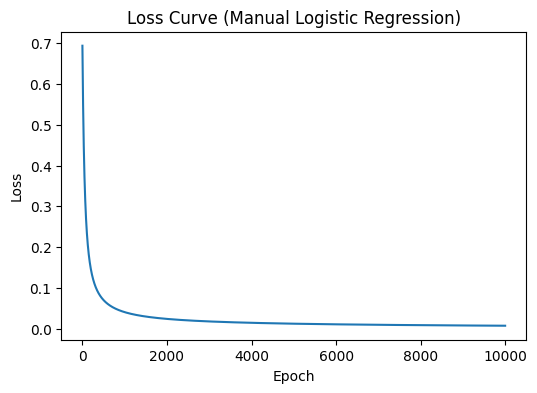

IL6     weight =  0.875
TNF     weight =  1.317
CXCL8   weight =  1.011
KLF2    weight = -1.327
PPARG   weight = -1.548
S1PR1   weight = -1.637
Gene7   weight =  0.046
Gene8   weight =  0.079
Gene9   weight =  0.256
Gene10  weight = -0.114
Gene11  weight =  0.138
Gene12  weight = -0.048


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. 样本数量
n_samples = 200
n_inf = n_samples // 2
n_norm = n_samples - n_inf

# 2. 构建 12 个基因表达矩阵
# 炎症组 
IL6_inf   = np.random.normal(loc=12, scale=3, size=100)
TNF_inf   = np.random.normal(loc=10, scale=2, size=100)
CXCL8_inf = np.random.normal(loc=14, scale=3, size=100)

KLF2_inf  = np.random.normal(loc=4, scale=1, size=100)
PPARG_inf = np.random.normal(loc=5, scale=1, size=100)
S1PR1_inf = np.random.normal(loc=3, scale=1, size=100)
noise_inf = [np.random.normal(8, 2, 100) for _ in range(6)]

X_inf = np.column_stack([
    IL6_inf, TNF_inf, CXCL8_inf,
    KLF2_inf, PPARG_inf, S1PR1_inf,
    *noise_inf
])

# 炎症组的标签为1（正类），所以标签集y要化为1向量
y_inf = np.ones((100,1))

# 健康组（Normal = 0）
IL6_norm   = np.random.normal(loc=6, scale=2, size=100)
TNF_norm   = np.random.normal(loc=5, scale=2, size=100)
CXCL8_norm = np.random.normal(loc=7, scale=2, size=100)

KLF2_norm  = np.random.normal(loc=8, scale=1, size=100)
PPARG_norm = np.random.normal(loc=9, scale=1, size=100)
S1PR1_norm = np.random.normal(loc=7, scale=1, size=100)

# Gene7–Gene12（6 个噪声基因）
noise_norm = [np.random.normal(loc=8, scale=2, size=100) for _ in range(6)]

# 拼接
X_norm = np.column_stack([
    IL6_norm, TNF_norm, CXCL8_norm,
    KLF2_norm, PPARG_norm, S1PR1_norm,
    *noise_norm
])

# 健康组标签为0（非正类），所以标签集要化为0向量
y_norm = np.zeros((100,1))



# 3. 合并
X = np.vstack([X_inf, X_norm])   # (200, 12)
y = np.vstack([y_inf, y_norm])   # (200, 1)


# 4. 标准化
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std



# 5. 手动逻辑回归
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

X_aug = np.hstack([np.ones((200,1)), X_scaled])  # 加截距列
w = np.zeros((13,1))  # 12 基因 + 截距

lr = 0.01
epochs = 10000

for epoch in range(epochs):
    z = X_aug.dot(w)
    y_hat = sigmoid(z)
    grad = (1/200) * X_aug.T.dot(y_hat - y)
    w -= lr * grad


# 6. 记录 loss 变化
w = np.zeros((13,1))  # 重新初始化权重
lr = 0.01
epochs = 10000
loss_list = []

for epoch in range(epochs):
    z = X_aug.dot(w)
    y_hat = sigmoid(z)

    # 计算 loss（交叉熵）
    loss = -np.mean(y * np.log(y_hat + 1e-8) + (1-y) * np.log(1 - y_hat + 1e-8))
    loss_list.append(loss)

    grad = (1/200) * X_aug.T.dot(y_hat - y)
    w -= lr * grad

# 绘制 loss 曲线
plt.figure(figsize=(6,4))
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (Manual Logistic Regression)")
plt.show()


# 7. 输出权重
theta0 = w[0,0]      # 截距
theta  = w[1:,0]     # 12 个基因的权重

gene_names = [
    "IL6", "TNF", "CXCL8",
    "KLF2", "PPARG", "S1PR1",
    "Gene7", "Gene8", "Gene9", "Gene10", "Gene11", "Gene12"
]

for name, c in zip(gene_names, theta):
    print(f"{name:6s}  weight = {c: .3f}")
